In [ ]:
import torch, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

DEVICE   = 0 if torch.cuda.is_available() else "cpu"
PKLOT = Path("archive/PKLot/PKLot/PKLot")
PKLOT_PUC = PKLOT /  "PUCPR"

SEG_ROOT = Path("archive/PKLot/PKLotSegmented")
DATA_DIR = Path("datasets/pklot_cls")
BEST_PT_A = "runs/classify/runs/cls_v1/weights/best.pt"
BEST_PT_B = "runs/classify/runs/cls_ft_puc5d/weights/best.pt"
best_A = YOLO(BEST_PT_A)
best_B = YOLO(BEST_PT_B)
print(PKLOT_PUC.exists())
print(PKLOT_PUC.rglob("*.jpg").__next__())
print(SEG_ROOT.exists())
print(SEG_ROOT.rglob("*.jpg").__next__())
print("device:", DEVICE,  "| best_A.pt:", BEST_PT_A, "| best_B.pt:", BEST_PT_B)

True
archive\PKLot\PKLot\PKLot\PUCPR\Cloudy\2012-09-12\2012-09-12_06_05_16.jpg
True
archive\PKLot\PKLotSegmented\PUC\Cloudy\2012-09-12\Empty\2012-09-12_06_05_16#001.jpg
device: 0 | best_A.pt: runs/classify/runs/cls_v1/weights/best.pt | best_B.pt: runs/classify/runs/cls_ft_puc5d/weights/best.pt


In [23]:
img_path = sorted(PKLOT_PUC.rglob("*.jpg"))[0]
xml_path = img_path.with_suffix(".xml")
img = cv2.imread(str(img_path))
print(img_path, xml_path, img.shape)

archive\PKLot\PKLot\PKLot\PUCPR\Cloudy\2012-09-12\2012-09-12_06_05_16.jpg archive\PKLot\PKLot\PKLot\PUCPR\Cloudy\2012-09-12\2012-09-12_06_05_16.xml (720, 1280, 3)


In [57]:
import xml.etree.ElementTree as ET
pkLotName = ET.parse(xml_path).getroot()
rows = []
for sp in pkLotName.iter("space"):
    rr = sp.find("rotatedRect")
    rows.append({
        "PKLot" : str(pkLotName.get("id")),
        "id" : int(sp.get("id")),
        "occupied" : sp.get("occupied"),
        "center_x" : float(sp.find("./rotatedRect/center").get("x")),
        "center_y" : float(sp.find("./rotatedRect/center").get("y")),
        "width" : float(sp.find("./rotatedRect/size").get("w")),
        "height" : float(sp.find("./rotatedRect/size").get("h")),
        "angle" : float(sp.find("./rotatedRect/angle").get("d")),
        "points" : [(int(p.get("x")), int(p.get("y"))) for p in sp.findall("contour/point")],
    })
slots = pd.DataFrame(rows)
print("주차면 수 : ", len(slots))
display(slots.head(5))


주차면 수 :  100


,PKLot,id,occupied,center_x,center_y,width,height,angle,points
0,pucpr,1,0,300.0,207.0,55.0,32.0,-74.0,"[(278, 230), (290, 186), (324, 185), (308, 230)]"
1,pucpr,2,0,332.0,209.0,56.0,33.0,-77.0,"[(325, 185), (355, 185), (344, 233), (310, 233)]"
2,pucpr,3,0,366.0,208.0,52.0,32.0,-77.0,"[(355, 185), (388, 186), (374, 233), (345, 230)]"
3,pucpr,4,0,398.0,207.0,54.0,36.0,-79.0,"[(389, 185), (421, 184), (412, 232), (375, 231)]"
4,pucpr,5,0,430.0,210.0,50.0,31.0,-75.0,"[(421, 187), (452, 190), (441, 232), (409, 231)]"


In [58]:
def crop_rotated(img, center_x, center_y, widthh, height, angle):
    # 회전된 사각형(중심, 크기, 각도)로 자르기  
    M = cv2.getRotationMatrix2D((center_x, center_y), angle, 1.0) # 사진 전체를 각도만큼 회전
    rooted = cv2.warpAffine(img, M, (img.shaepe[1], img.shape[0])) # 회전 적용 -> 주차면이 똑바로 섬
    return cv2.getRectSubPix(rooted, (int(widthh), int(height)), (center_x, center_y)) # 중심기준 wxh 크기만큼 잘라서 리턴
def order_points(pts):
    """꼭짓점 4개를 [왼위, 오위, 오아래, 왼아래] 순서로 정렬"""
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(1)                    # x+y: 가장 작으면 왼위, 가장 크면 오아래
    d = np.diff(pts, axis=1).ravel()  # y-x: 가장 작으면 오위, 가장 크면 왼아래
    return np.array([pts[s.argmin()], pts[d.argmin()], pts[s.argmax()], pts[d.argmax()]], np.float32)

def crop_quad(img, pts):
    """꼭짓점 4개로 원근 보정해서 자르기 → 나중에 내 주차장(ParkingPtsSelection 좌표)에서 쓸 방식"""
    tl, tr, br, bl = order_points(pts)
    w = int(max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl)))
    h = int(max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr)))
    dst = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], np.float32)
    M = cv2.getPerspectiveTransform(np.array([tl, tr, br, bl]), dst)
    return cv2.warpPerspective(img, M, (w, h))

TypeError: expected str, bytes or os.PathLike object, not ndarray

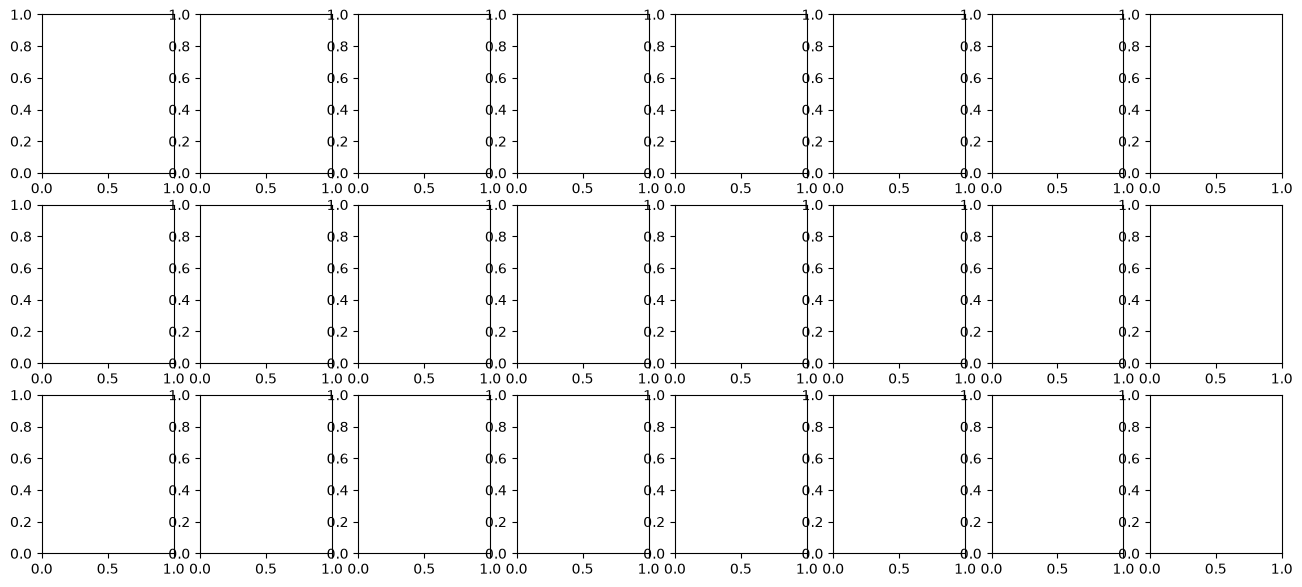

In [ ]:
SEG_PUC = SEG_ROOT / "PUC"


stem, date = img_path.stem, img_path.parent.name
weather = img_path.parent.parent.name

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for col, s in enumerate(slots.sample(8, random_state=0).itertuples()):
    seg_files = list((SEG_PUC / weather / date).glob(f"*/{stem}#{s.id:03d}.jpg"))
    seg = cv2.imread(str(seg_files[0])) if seg_files else np.zeros((10, 10, 3), np.uint8)
    #print(Path(img))
    a = crop_rotated(img, s.center_x, s.center_y, s.width, s.height, s.angle)
    b = crop_quad(img, s.pts)
    for row, (im, name) in enumerate([(seg, "PKLot"), (a, "rotated"), (b, "quad")]):
        axes[row, col].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(f"#{s.id} {name}\n{im.shape[1]}x{im.shape[0]}", fontsize=7)
        axes[row, col].axis("off")
plt.tight_layout(); plt.show()


In [64]:
print(stem, date)
print(weather)

2012-09-12_06_05_16 2012-09-12
Cloudy
